In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

a = np.array([1, 2, 3, 4, 5])
b = np.array([5, 4, 3, 2, 1])
c = a + b
print(c)

[6 6 6 6 6]


In [2]:
#  dot product (a⋅b=a1​b1​+a2​b2​+⋯+an​bn​)
dot_product = np.dot(a, b)
print(dot_product)


35


In [3]:

A = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
A.dot(np.eye(3))  # multiplying by identity matrix returns the same matrix



array([[1., 2., 3.],
       [4., 5., 6.],
       [7., 8., 9.]])

In [ ]:
# transpose of a matrix
print(A.T)
B = np.array([[9, 8, 7], [6, 5, 4], [3, 2, 1]])

print(A.T + B.T)  # equals A + B transposed
print((A + B).T)

In [4]:
# Using Pandas, calculate the mean, median, mode, variance, and standard deviation for the following variables:
# Applicant_Income


# Loan_Amount


# Age
import pandas as pd
data = pd.read_excel('data.xlsx')

applicant_income = data['Applicant_Income']
loan_amount = data['Loan_Amount']
age = data['Age']
print(applicant_income)
print(loan_amount)
print(age)


0      56976
1       1856
2      64553
3      88450
4       9539
       ...  
995    44713
996    70886
997    24392
998    64803
999    22938
Name: Applicant_Income, Length: 1000, dtype: int64
0      8031545
1       899361
2      2387748
3       658856
4       198671
        ...   
995    5883603
996    2780228
997     301249
998     719891
999      61019
Name: Loan_Amount, Length: 1000, dtype: int64
0      36
1      42
2      38
3      32
4      35
       ..
995    35
996    37
997    28
998    33
999    24
Name: Age, Length: 1000, dtype: int64


In [1]:
import pandas as pd
data = pd.read_excel('data.xlsx')

applicant_income = data['Applicant_Income']
applicant_income_cv = (applicant_income.std() / applicant_income.mean()) * 100

annual_household_income = data['Annual_Household_Income']
annual_household_income_cv = (annual_household_income.std() / annual_household_income.mean()) * 100

print(f"Applicant Income CV: {applicant_income_cv}")
print(f"Annual Household Income CV: {annual_household_income_cv}")

if applicant_income_cv < annual_household_income_cv:
    print("Applicant Income is more stable.")
else:
    print("Annual Household Income is more stable.")

Applicant Income CV: 66.304909203322
Annual Household Income CV: 75.48570561402512
Applicant Income is more stable.


In [ ]:
#2  Compute the five-number summary (minimum, first quartile, median, third quartile, maximum) for the CIBIL_Score column. What does this tell you about the creditworthiness distribution of applicants?
cibil_score = data['CIBIL_Score'] 
five_number_summary = cibil_score.describe()[['min', '25%', '50%', '75%', 'max']]
print("Five-number summary for CIBIL_Score:")
print(five_number_summary)



Five-number summary for CIBIL_Score:
min    384.00
25%    605.75
50%    654.00
75%    704.00
max    878.00
Name: CIBIL_Score, dtype: float64


In [19]:
#3
applicant_income_cv = (applicant_income.std() / applicant_income.mean()) * 100
annual_household_income = data['Annual_Household_Income']
annual_household_income_cv = (annual_household_income.std() / annual_household_income.mean()) * 100
print(f"Applicant Income CV: {applicant_income_cv}")
print(f"Annual Household Income CV: {annual_household_income_cv}")
if applicant_income_cv < annual_household_income_cv:
    print("Applicant Income is more stable.")
else:
    print("Annual Household Income is more stable.")

Applicant Income CV: 66.304909203322
Annual Household Income CV: 75.48570561402512
Applicant Income is more stable.


In [29]:
#4
total_applicants = len(data)
loan_aproved = len(data[data['Loan_Status'] == 'Approved'])
loan_approved_prob = loan_aproved / total_applicants

good_credit = len(data[data['Credit_History'] == 1])
good_credit_prob = good_credit / total_applicants

approved_and_good_credit = len(data[(data['Loan_Status'] == 'Approved') & (data['Credit_History'] == 1)])
approved_and_good_credit_prob = approved_and_good_credit / total_applicants
print(f"Probability of loan approval: {loan_approved_prob}")
print(f"Probability of good credit history: {good_credit_prob}")
print(f"Probability of loan approval and good credit history: {approved_and_good_credit_prob}")

Probability of loan approval: 0.653
Probability of good credit history: 0.723
Probability of loan approval and good credit history: 0.536
723


In [32]:
#5 
good_credit = data[data["Credit_History"] == 1]
approved_given_good_credit = good_credit[good_credit["Loan_Status"] == "Approved"]
approved_given_good_credit_prob = len(approved_given_good_credit) / len(good_credit)
print(f"Probability of loan approval given good credit history: {approved_given_good_credit_prob}")


Probability of loan approval given good credit history: 0.7413554633471646


In [36]:
#6
total_applicants = len(data)
no_of_self_employed_prob = len(data[data['Employment_Status'] == 'Self-Employed']) / total_applicants
has_loan_amount_grt_10Lak_prob = len(data[data['Loan_Amount'] > 1000000]) / total_applicants
print(f"Probability of being self-employed: {no_of_self_employed_prob}")
print(f"Probability of having loan amount greater than 10 lakhs: {has_loan_amount_grt_10Lak_prob}")

Probability of being self-employed: 0.244
Probability of having loan amount greater than 10 lakhs: 0.493


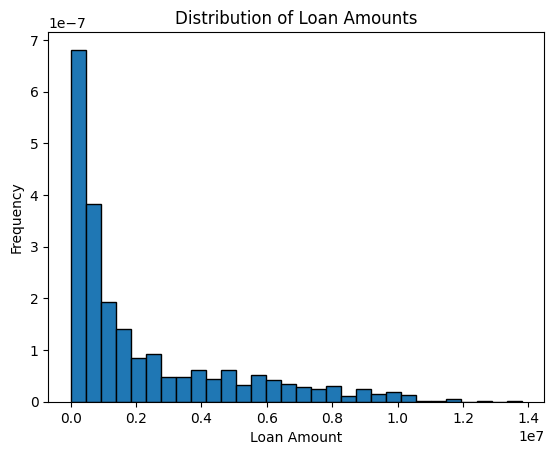

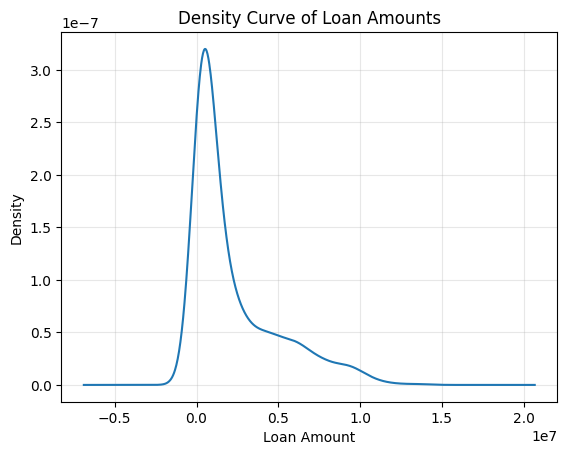

In [64]:
# Random Variables & Distributions
#7
plt.hist(data['Loan_Amount'], bins=30, edgecolor='black', density=True)
plt.title('Distribution of Loan Amounts')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

data['Loan_Amount'].plot(kind= 'kde')
plt.title('Density Curve of Loan Amounts')
plt.xlabel('Loan Amount')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)
plt.show()

In [68]:
#8

from scipy.stats import shapiro

static, p_value = shapiro(data['Loan_Amount'])
print(f"Shapiro-Wilk Test Statistic: {static}, p-value: {p_value}")


Shapiro-Wilk Test Statistic: 0.7764803983116321, p-value: 7.926906331531401e-35


In [72]:
#9
approved_applicants = data[data['Loan_Status'] == 'Approved']
approved_urban_applicants = approved_applicants[approved_applicants['Property_Area'] == 'Urban']
print(len(approved_urban_applicants))
approval_rate_urban = len(approved_urban_applicants) / len(approved_applicants)
print(f"Loan approval rate for urban applicants: {approval_rate_urban}")

240
Loan approval rate for urban applicants: 0.3675344563552833


In [78]:
#10

approved_given_good_credit = data[(data['Loan_Status'] == 'Approved') & (data['Credit_History'] == 1)]
approval_rate_good_credit = len(approved_given_good_credit) / len(data[data['Credit_History'] == 1])

total = len(data)

good_credit = data[data["Credit_History"] == 1]
prob_good_credit = len(good_credit) / total

approved_loan = data[data['Loan_Status'] == 'Approved']
prob_approved_loan = len(approved_loan) / total

#Bayes Theorem
prob_good_credit_given_approved_loan =(approval_rate_good_credit * prob_good_credit) / prob_approved_loan
print(f"Probability of good credit history given loan approval: {prob_good_credit_given_approved_loan}")

# Direct compute from dataset
appreoved_with_good_credit = data[(data['Loan_Status'] == 'Approved') & (data['Credit_History'] == 1)]
prob_good_credit_given_approved_loan_direct = len(appreoved_with_good_credit) / len(data[data['Loan_Status'] == 'Approved'])
print(f"Direct Probability of good credit history given loan approval: {prob_good_credit_given_approved_loan_direct}")

Probability of good credit history given loan approval: 0.8208269525267994
Direct Probability of good credit history given loan approval: 0.8208269525267994


In [82]:
#11

variables = ['Applicant_Income', 'Loan_Amount', 'CIBIL_Score', 'Debt_to_Income_Ratio']

cov_matrix = data[variables].cov()
print(f"Covariance Matrix : \n {cov_matrix}")

Covariance Matrix : 
                       Applicant_Income   Loan_Amount   CIBIL_Score  \
Applicant_Income          7.914775e+08  7.533140e+08  6.380233e+04   
Loan_Amount               7.533140e+08  6.943335e+12  3.160924e+06   
CIBIL_Score               6.380233e+04  3.160924e+06  5.451835e+03   
Debt_to_Income_Ratio     -6.275243e+06  5.877618e+07  3.442670e+03   

                      Debt_to_Income_Ratio  
Applicant_Income             -6.275243e+06  
Loan_Amount                   5.877618e+07  
CIBIL_Score                   3.442670e+03  
Debt_to_Income_Ratio          3.899042e+06  


In [84]:
#12
corr_loan_income = data['Loan_Amount'].corr(data['Annual_Household_Income'])
print(f"Correlation between Loan Amount and Annual Household Income: {corr_loan_income}")

corr_loan_cibil = data['Loan_Amount'].corr(data['CIBIL_Score'])
print(f"Correlation between Loan Amount and CIBIL Score: {corr_loan_cibil}")

Correlation between Loan Amount and Annual Household Income: 0.028714914693769782
Correlation between Loan Amount and CIBIL Score: 0.016246456713254375


In [90]:
#13
from scipy.stats import ttest_ind

graduated = data[data['Education'] == 'Graduate']['Loan_Amount']
non_graduated = data[data['Education'] == 'Not Graduate']['Loan_Amount']

print(sum(graduated))
print(sum(non_graduated))

t_stat, p_value = ttest_ind(graduated, non_graduated, equal_var=False)
print(f"T-statistic: {t_stat}, p-value: {p_value}")

1556516823
660196078
T-statistic: -0.8750098641799476, p-value: 0.3819754674553013


In [94]:
#14
from scipy.stats import chi2_contingency

table = pd.crosstab(data['Gender'], data['Loan_Status'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
print(f"Chi-squared Statistic: {chi2}, dof: {dof}, p-value: {p}")

Loan_Status  Approved  Rejected
Gender                         
Female            225       113
Male              420       231
Other               8         3
Chi-squared Statistic: 0.6841854378215771, dof: 2, p-value: 0.7102823450506209


In [96]:
# 15

from scipy import stats


loan_amount = data['Loan_Amount']

loan_amount_mean = loan_amount.mean()
loan_amount_std = loan_amount.std(ddof=1)
n = len(loan_amount)

# 95% confidence interval (t-distribution)
confidence_level = 0.95
alpha = 1 - confidence_level
t_critical = stats.t.ppf(1 - alpha/2, df=n-1)

margin_error = t_critical * (loan_amount_std / np.sqrt(n))

ci_lower = loan_amount_mean - margin_error
ci_upper = loan_amount_mean + margin_error

print("Mean Loan Amount:", loan_amount_mean)
print("95% Confidence Interval:", (ci_lower, ci_upper))

Mean Loan Amount: 2216712.901
95% Confidence Interval: (np.float64(2053197.5053930872), np.float64(2380228.296606913))


In [99]:
#16
dti = data["Debt_to_Income_Ratio"]

# Sample statistics
mean_dti = dti.mean()
std_dti = dti.std(ddof=1)
n = len(dti)

# 95% confidence interval using t-distribution
confidence_level = 0.95
alpha = 1 - confidence_level
t_critical = stats.t.ppf(1 - alpha/2, df=n-1)

margin_error = t_critical * (std_dti / np.sqrt(n))

ci_lower = mean_dti - margin_error
ci_upper = mean_dti + margin_error

print("Mean DTI:", mean_dti)
print("95% Confidence Interval for DTI:", (ci_lower, ci_upper))

Mean DTI: 148.118157
95% Confidence Interval for DTI: (np.float64(25.585030421237192), np.float64(270.6512835787628))


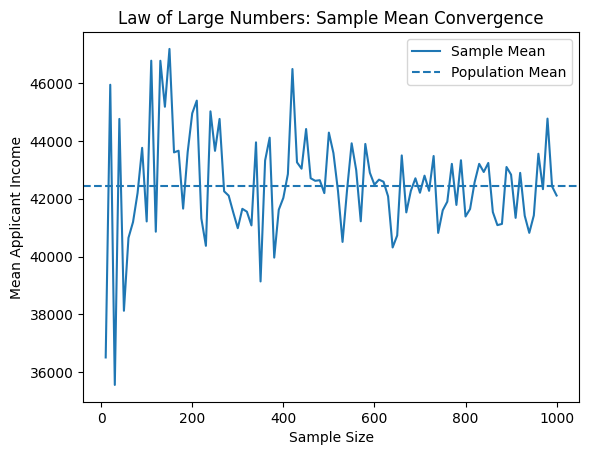

In [102]:
#17

income = data["Applicant_Income"].values
population_mean = income.mean()

# Increasing sample sizes
sample_sizes = range(10, 1001, 10)
sample_means = []

np.random.seed(42)

for n in sample_sizes:
    sample = np.random.choice(income, size=n, replace=True)
    sample_means.append(sample.mean())

plt.figure()
plt.plot(sample_sizes, sample_means, label="Sample Mean")
plt.axhline(population_mean, linestyle="--", label="Population Mean")
plt.xlabel("Sample Size")
plt.ylabel("Mean Applicant Income")
plt.title("Law of Large Numbers: Sample Mean Convergence")
plt.legend()
plt.show()



In [108]:
#18

data["Loan_Status_Bernoulli"] = data["Loan_Status"].map(
    {"Approved": 1, "Rejected": 0}
)
# print(data["Loan_Status_Bernoulli"].head())

# Mean and variance
mean_bernoulli = data["Loan_Status_Bernoulli"].mean()
variance_bernoulli = data["Loan_Status_Bernoulli"].var(ddof=0)  # population variance
print(f"Mean of Bernoulli Loan Status: {mean_bernoulli}")
print(f"Variance of Bernoulli Loan Status: {variance_bernoulli}")

Mean of Bernoulli Loan Status: 0.653
Variance of Bernoulli Loan Status: 0.22659100000000001


In [110]:
#19

from scipy.stats import binom

# Parameters
n = 50          # number of applicants
p = 0.653       # probability of approval

# Probability that at least 30 loans are approved
prob_at_least_30 = 1 - binom.cdf(29, n, p)

print("P(X ≥ 30):", prob_at_least_30)


P(X ≥ 30): 0.8258327592239827


In [112]:
# High-quality borrower segment
segment = data[
    (data["CIBIL_Score"] > 750) &
    (data["Debt_to_Income_Ratio"] < 0.35)
]

# Empirical probability of approval
empirical_probability = (
    len(segment[segment["Loan_Status"] == "Approved"]) / len(segment)
)

print("Number of applicants in segment:", len(segment))
print("Empirical P(Approved):", empirical_probability)

Number of applicants in segment: 45
Empirical P(Approved): 1.0


In [114]:
#20


# Expected loan amount given loan is approved
expected_loan_given_approved = (
    data[data["Loan_Status"] == "Approved"]["Loan_Amount"].mean()
)

print("E(Loan Amount | Approved):", expected_loan_given_approved)

E(Loan Amount | Approved): 1866064.245022971


In [116]:
# 21


# Expected loan amount given loan is approved
expected_loan_given_approved = (
    data[data["Loan_Status"] == "Approved"]["Loan_Amount"].mean()
)

print("E(Loan Amount | Approved):", expected_loan_given_approved)

E(Loan Amount | Approved): 1866064.245022971


In [ ]:
from scipy.stats import pointbiserialr

data["Loan_Status_Binary"] = data["Loan_Status"].map({"Approved": 1, "Rejected": 0})

variables = [
    "CIBIL_Score",
    "Debt_to_Income_Ratio",
    "Employment_Length_Years"
]

for var in variables:
    corr, pval = pointbiserialr(data["Loan_Status_Binary"], data[var])
    print(var, "Correlation:", corr, "p-value:", pval)